In [8]:
import pandas as pd
final_df = pd.read_csv('/Users/ozgeyavuz/synthbuster/dalle2/base_df.csv')
final_df2 = pd.read_csv('/Users/ozgeyavuz/synthbuster/midjourney-v5/base_df.csv')
final_df3 = pd.read_csv('/Users/ozgeyavuz/synthbuster/stable-diffusion-1-4/base_df.csv')
# Add model labels
final_df['model'] = 'dalle2'
final_df2['model'] = 'midjourney-v5'
final_df3['model'] = 'stable-diffusion-1-4'

# Combine all into one DataFrame
all_df = pd.concat([final_df, final_df2, final_df3], ignore_index=True)



In [9]:
import ast

# Safely convert string representation of list/tuple to actual Python object
all_df[['most_common_color_R', 'most_common_color_G', 'most_common_color_B']] = all_df['most_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df[['least_common_color_R', 'least_common_color_G', 'least_common_color_B']] = all_df['least_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df = all_df.drop(columns=['most_common_color', 'least_common_color'])
all_df.head()
#most common percentage
all_df[['most_common_percentage_1', 'most_common_percentage_2', 'most_common_percentage_3']] = all_df['most_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df[['least_common_percentage_1', 'least_common_percentage_2', 'least_common_percentage_3']] = all_df['least_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df = all_df.drop(columns=['most_common_percentage', 'least_common_percentage'])     
all_df.head()

,image,prompt,avg_brightness,max_brightness,min_brightness,contrast,avg_saturation,max_saturation,min_saturation,horizontal_symmetry,...,most_common_color_B,least_common_color_R,least_common_color_G,least_common_color_B,most_common_percentage_1,most_common_percentage_2,most_common_percentage_3,least_common_percentage_1,least_common_percentage_2,least_common_percentage_3
0,/Users/ozgeyavuz/synthbuster/dalle2/r17fe8532t...,r17fe8532t,133.124648,255.0000,0.0000,71.515001,38.989592,255.0,0.0,0.307190,...,214,226,226,217,0.10223,0.09489,0.09089,0.0001,0.0001,0.0001
1,/Users/ozgeyavuz/synthbuster/dalle2/r0648cff8t...,r0648cff8t,115.525865,255.0000,3.5748,57.524662,55.867724,255.0,0.0,0.121212,...,255,168,159,156,0.02375,0.01392,0.01383,0.0001,0.0001,0.0001
2,/Users/ozgeyavuz/synthbuster/dalle2/r1c243af7t...,r1c243af7t,142.339941,255.0000,0.8504,51.571350,99.460009,255.0,0.0,0.052151,...,223,141,120,39,0.02317,0.02241,0.02203,0.0001,0.0001,0.0001
3,/Users/ozgeyavuz/synthbuster/dalle2/r1800ab47t...,r1800ab47t,94.856203,254.5748,0.0000,47.815381,92.816821,255.0,0.0,0.155678,...,10,175,152,84,0.00973,0.00896,0.00868,0.0001,0.0001,0.0001
4,/Users/ozgeyavuz/synthbuster/dalle2/r09d5cb41t...,r09d5cb41t,144.620833,244.6070,17.0458,42.049943,109.927796,255.0,0.0,0.260665,...,152,146,135,128,0.02966,0.02937,0.02861,0.0001,0.0001,0.0001


In [10]:
print(all_df.columns)

Index(['image', 'prompt', 'avg_brightness', 'max_brightness', 'min_brightness',
       'contrast', 'avg_saturation', 'max_saturation', 'min_saturation',
       'horizontal_symmetry', 'vertical_symmetry', 'sharpness', 'edge_density',
       'whitespace_ratio', 'model', 'most_common_color_R',
       'most_common_color_G', 'most_common_color_B', 'least_common_color_R',
       'least_common_color_G', 'least_common_color_B',
       'most_common_percentage_1', 'most_common_percentage_2',
       'most_common_percentage_3', 'least_common_percentage_1',
       'least_common_percentage_2', 'least_common_percentage_3'],
      dtype='object')


In [11]:
# print(all_df.groupby('model')['most_common_percentage_3'].unique())
# print(all_df.groupby('model')['most_common_percentage_2'].unique())
# print(all_df.groupby('model')['most_common_percentage_1'].unique())

# print("----------------")
print(all_df.groupby('model')['least_common_percentage_3'].unique())
print(all_df.groupby('model')['least_common_percentage_2'].unique())
print(all_df.groupby('model')['least_common_percentage_1'].unique())



model
dalle2                         [0.0001]
midjourney-v5           [8e-05, 0.0001]
stable-diffusion-1-4          [0.00038]
Name: least_common_percentage_3, dtype: object
model
dalle2                         [0.0001]
midjourney-v5           [8e-05, 0.0001]
stable-diffusion-1-4          [0.00038]
Name: least_common_percentage_2, dtype: object
model
dalle2                         [0.0001]
midjourney-v5           [8e-05, 0.0001]
stable-diffusion-1-4          [0.00038]
Name: least_common_percentage_1, dtype: object


In [12]:
all_df = all_df.drop(columns=['least_common_percentage_1','least_common_percentage_2','least_common_percentage_3'])

# cols_to_standardize_bool = (
#     all_df.columns.str.contains("max") |
#     all_df.columns.str.contains("min") |
#     all_df.columns.str.contains("most") |
#     all_df.columns.str.contains("least")
# )

# # Get the actual names of the columns to standardize
# cols_to_standardize = all_df.columns[cols_to_standardize_bool]

# print("Columns to standardize:")
# print(cols_to_standardize)
# print("-" * 30)

# # 2. Apply standardization only to these selected columns
# # We use .loc to select both rows (all) and columns (cols_to_standardize)
# # Then, we apply a lambda function column-wise (axis=0)
# all_df.loc[:, cols_to_standardize] = all_df.loc[:, cols_to_standardize].apply(
#     lambda x: (x - x.mean()) / x.std(), axis=0
# )
# all_df

In [20]:
(all_df.columns)

Index(['image', 'prompt', 'avg_brightness', 'max_brightness', 'min_brightness',
       'contrast', 'avg_saturation', 'max_saturation', 'min_saturation',
       'horizontal_symmetry', 'vertical_symmetry', 'sharpness', 'edge_density',
       'whitespace_ratio', 'model', 'most_common_color_R',
       'most_common_color_G', 'most_common_color_B', 'least_common_color_R',
       'least_common_color_G', 'least_common_color_B',
       'most_common_percentage_1', 'most_common_percentage_2',
       'most_common_percentage_3'],
      dtype='object')

In [13]:

# print(all_df.groupby('model')['max_brightness'].unique())
# print(all_df.groupby('model')['min_brightness'].unique())
# print("----------------")
# print(all_df.groupby('model')['max_saturation'].unique())
# print(all_df.groupby('model')['min_saturation'].unique())
# print("----------------")
# print(all_df.groupby('model')['least_common_color_R'].unique())
# print(all_df.groupby('model')['least_common_color_G'].unique())
# print(all_df.groupby('model')['least_common_color_B'].unique())
# print("----------------")
# print(all_df.groupby('model')['most_common_color_R'].unique())
# print(all_df.groupby('model')['most_common_color_G'].unique())
# print(all_df.groupby('model')['most_common_color_B'].unique())




analysis for column : avg_brightness
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 365.3607 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for avg_brightness


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


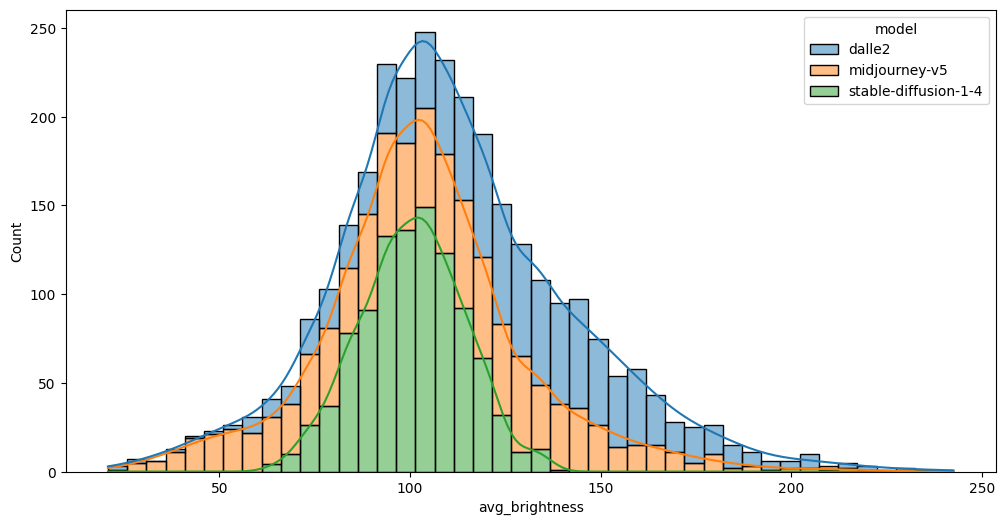

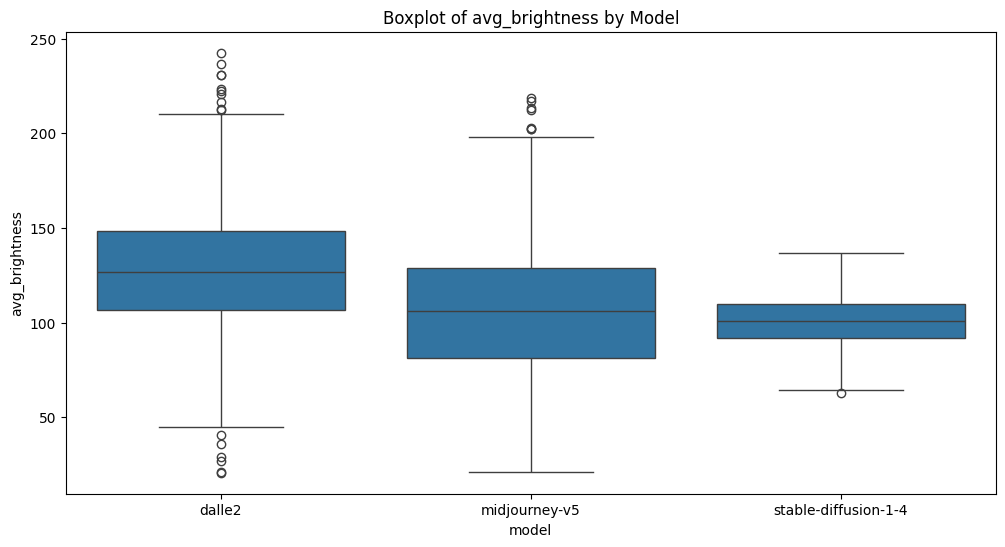

analysis for column : max_brightness
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model  7.7988 2.0000 1998.0000 0.0004


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for max_brightness


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


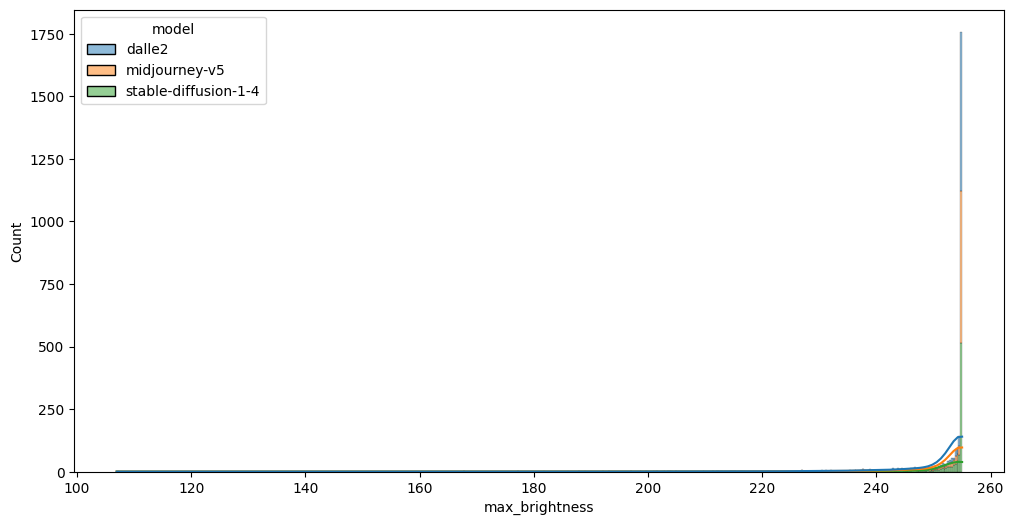

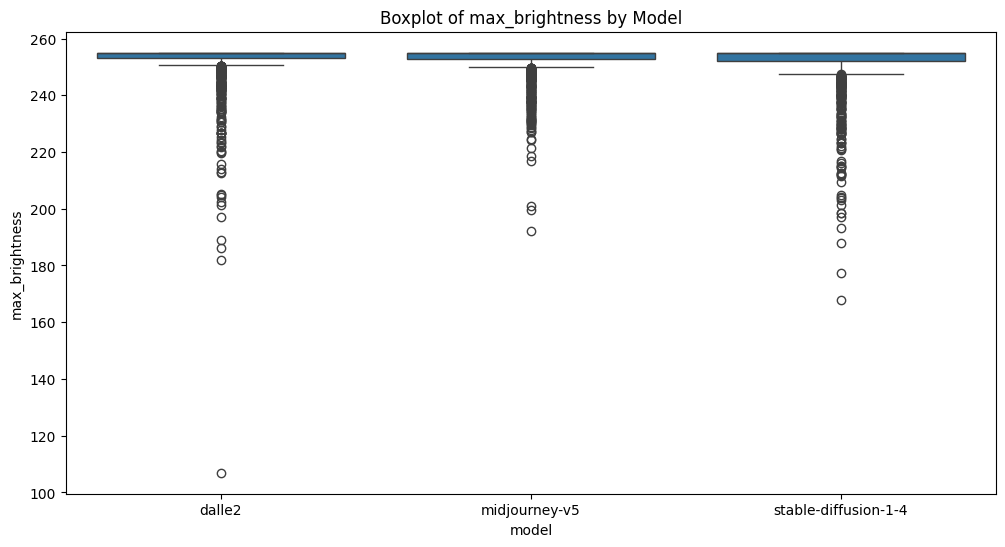

analysis for column : min_brightness


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1073d9ee0>>
Traceback (most recent call last):
  File "/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 185.6551 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for min_brightness


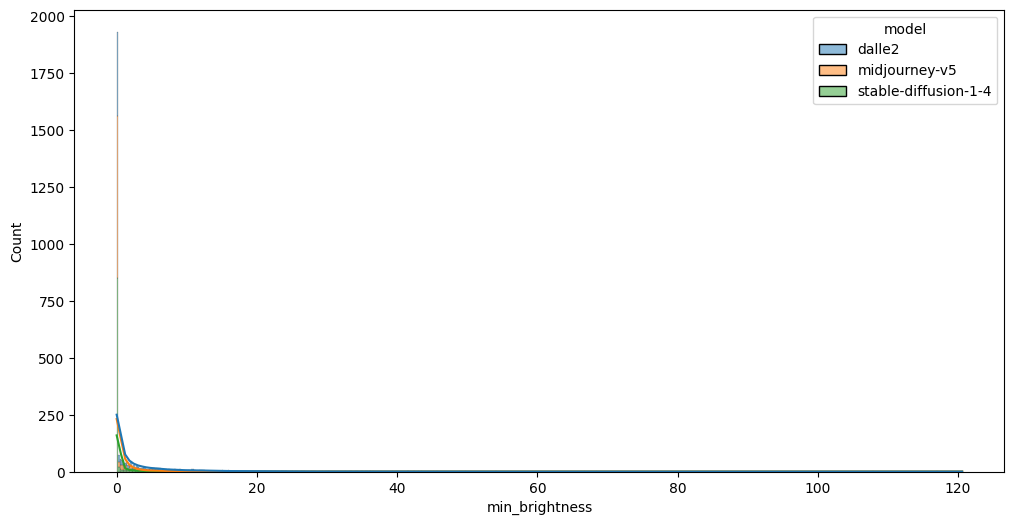

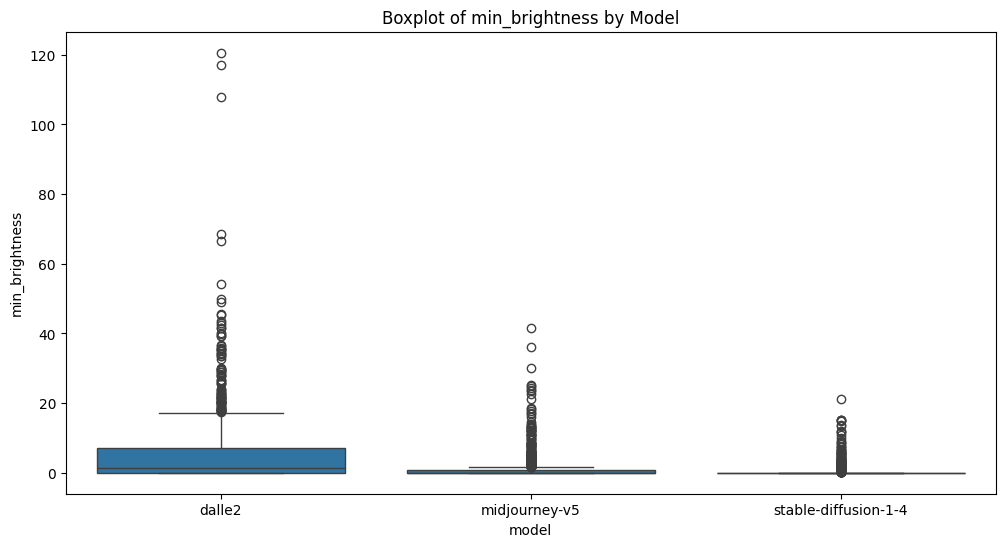

analysis for column : contrast
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 113.5376 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for contrast


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


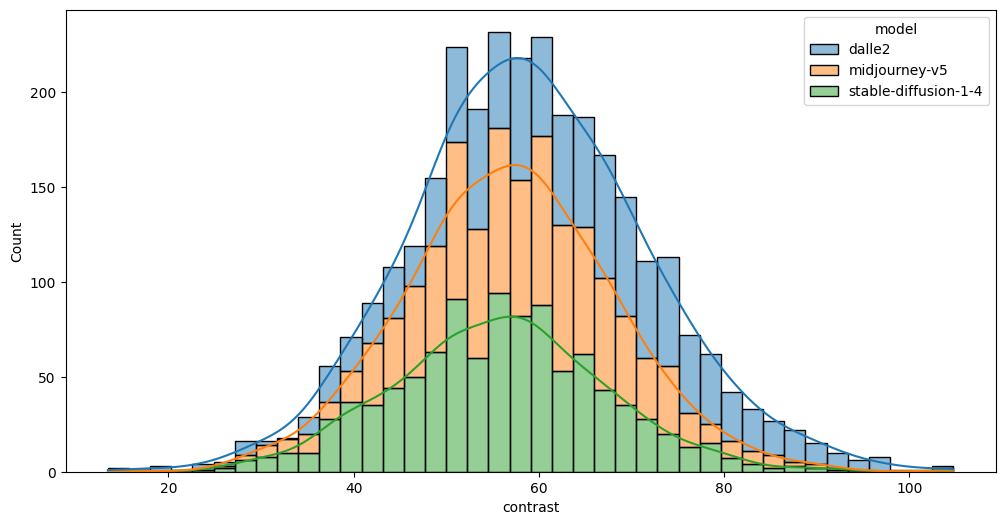

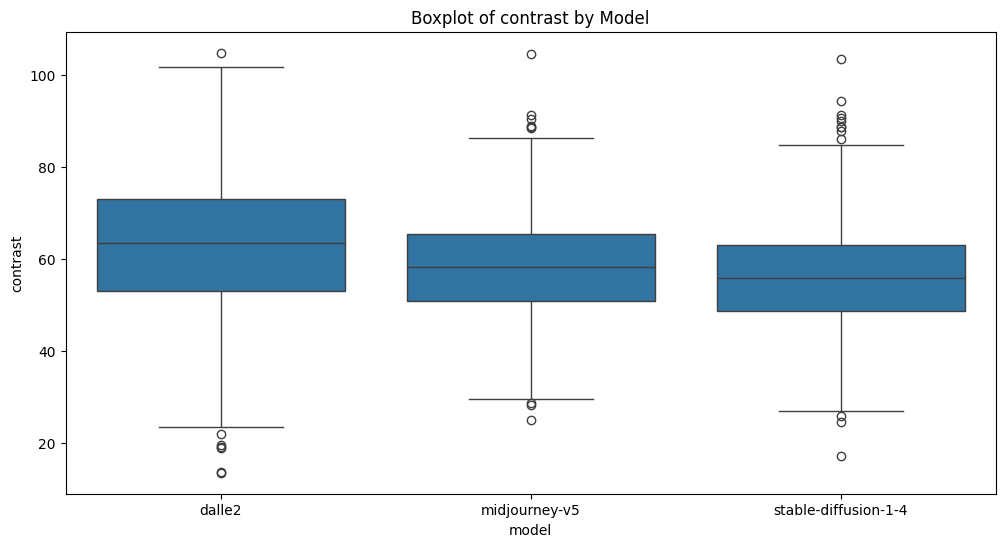

analysis for column : avg_saturation
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model 94.0223 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for avg_saturation


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


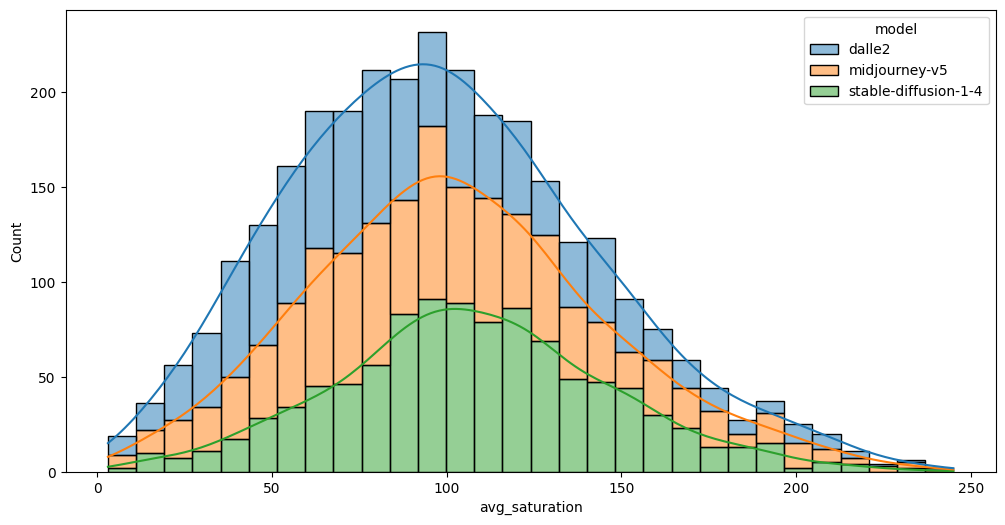

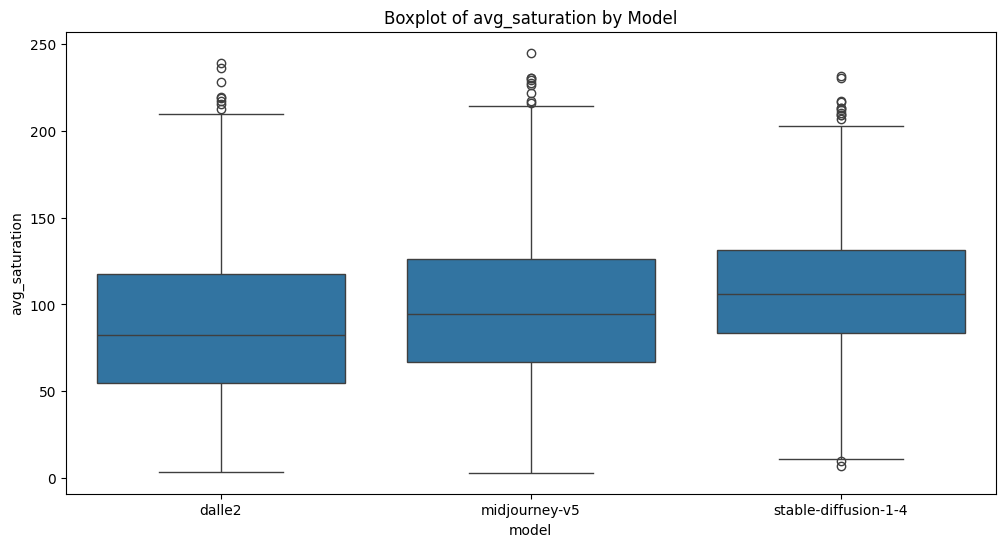

analysis for column : max_saturation
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model 42.3254 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for max_saturation


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


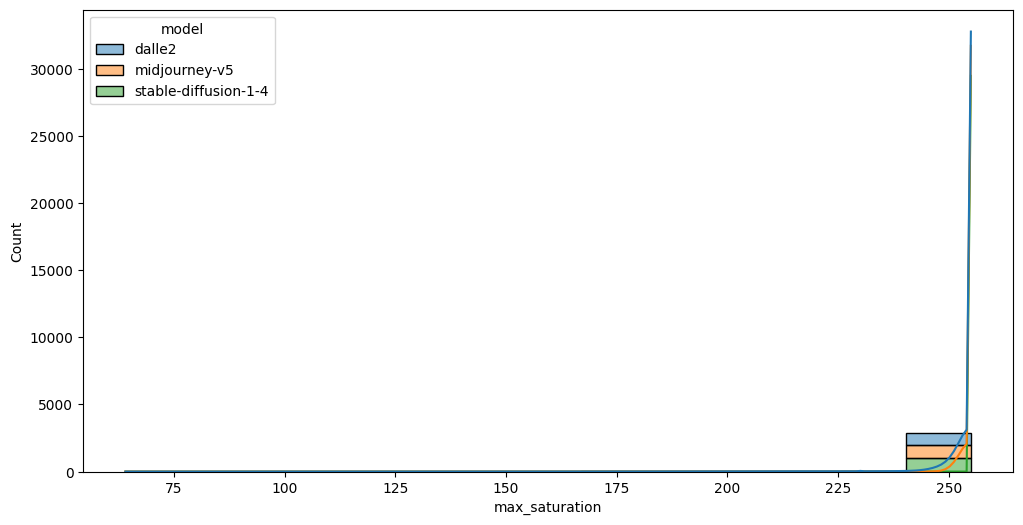

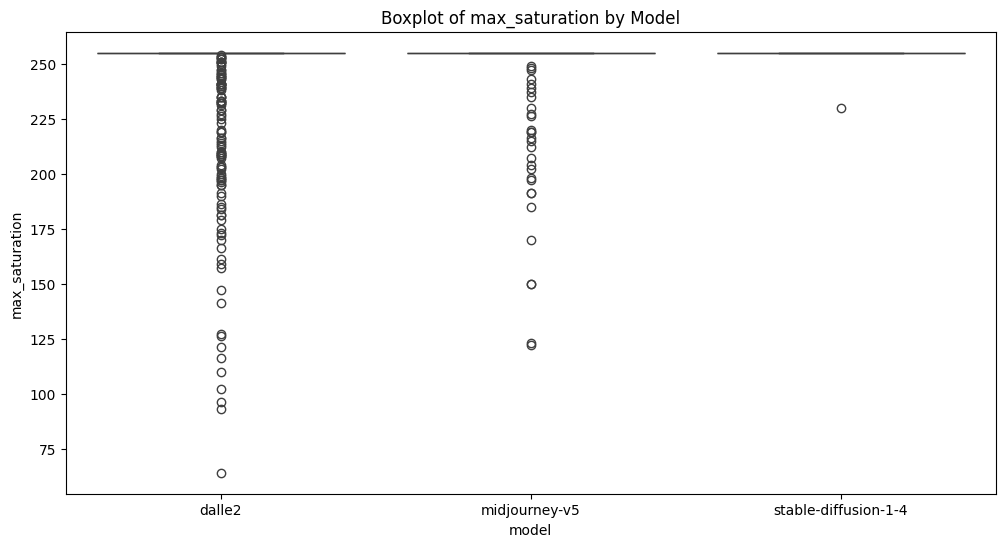

analysis for column : min_saturation
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model  2.0468 2.0000 1998.0000 0.1294


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for min_saturation


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


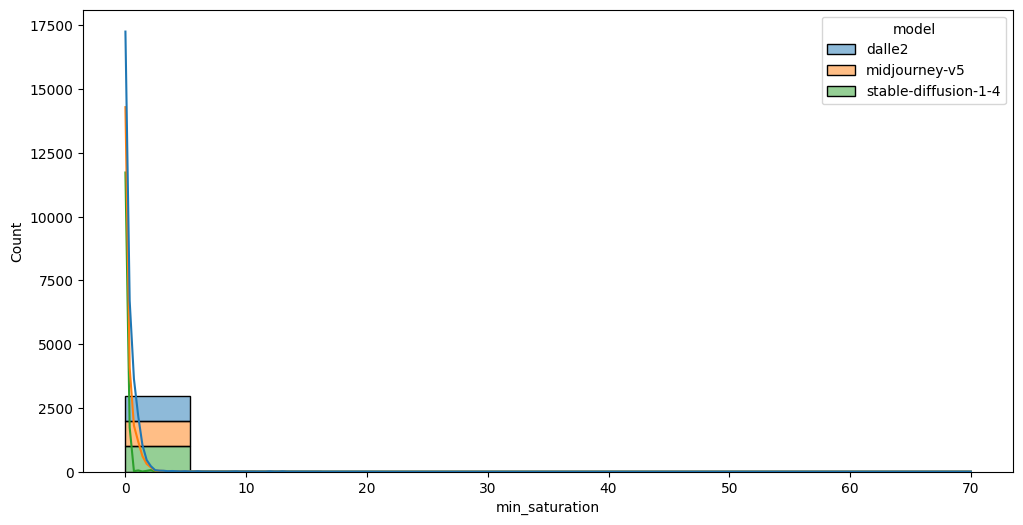

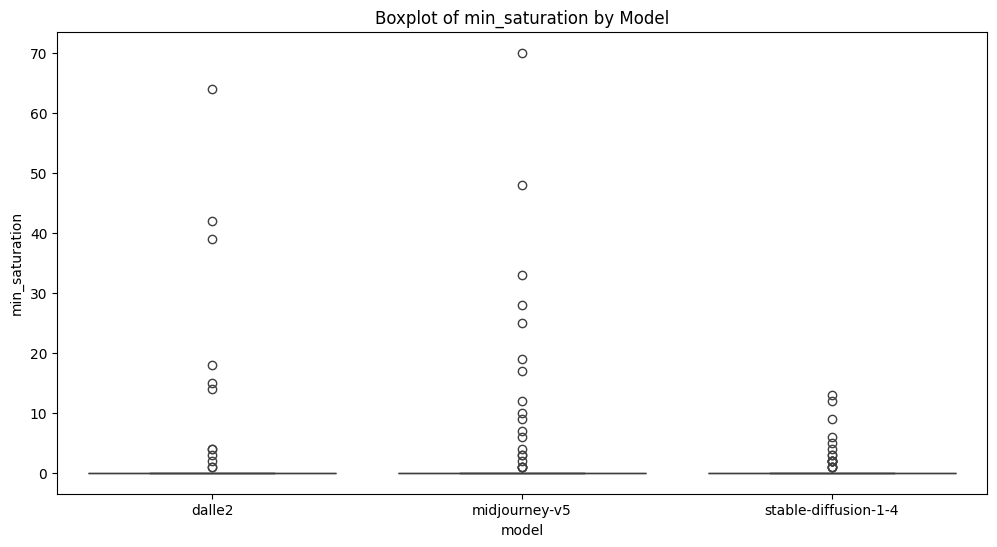

analysis for column : horizontal_symmetry
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 183.6207 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for horizontal_symmetry


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


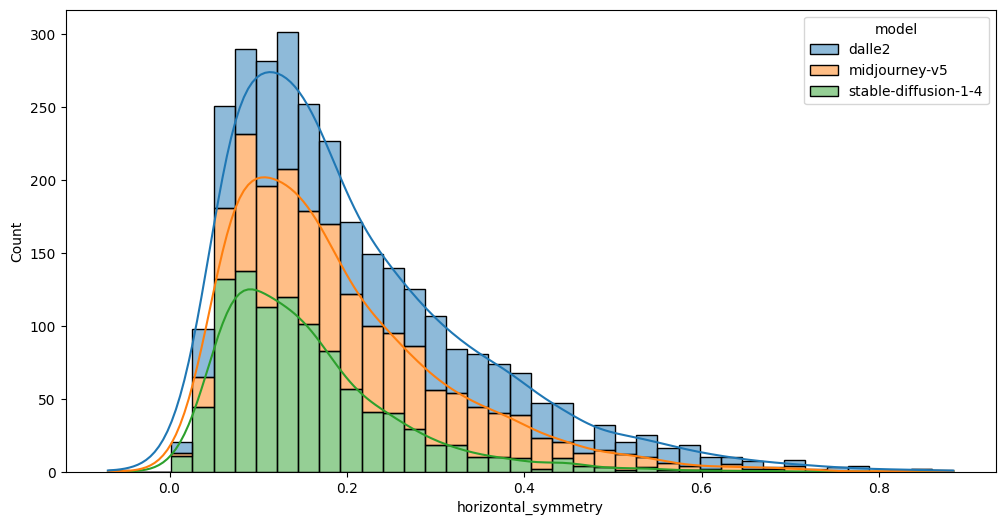

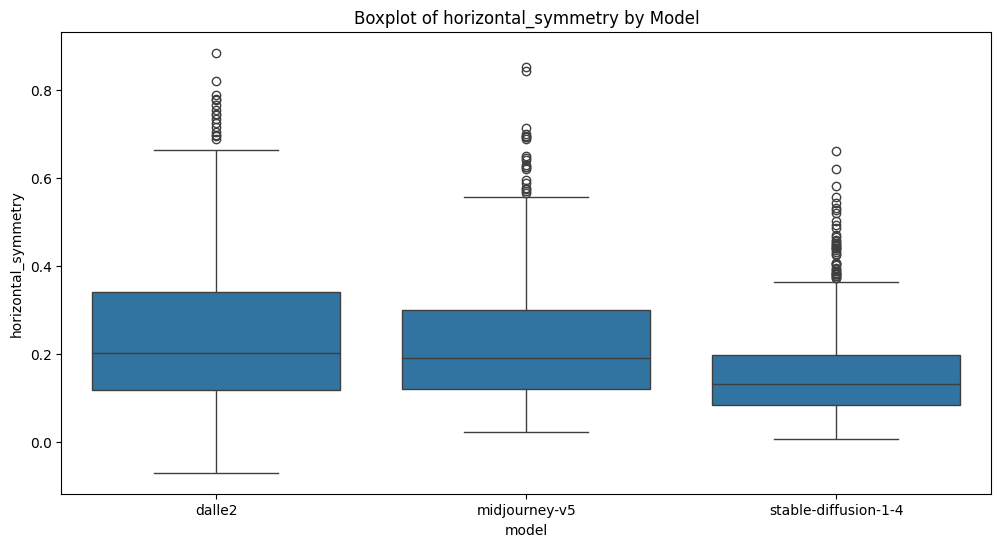

analysis for column : vertical_symmetry
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 219.0840 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for vertical_symmetry


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


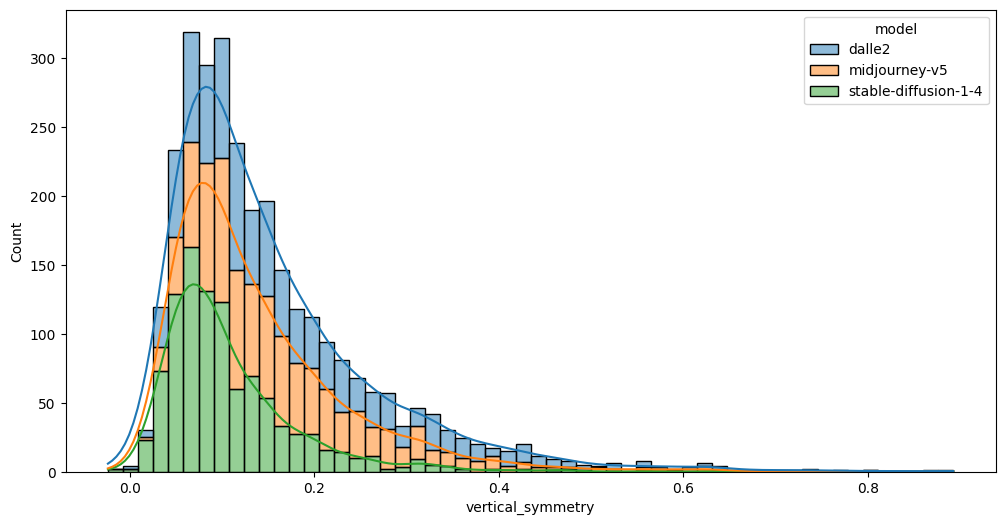

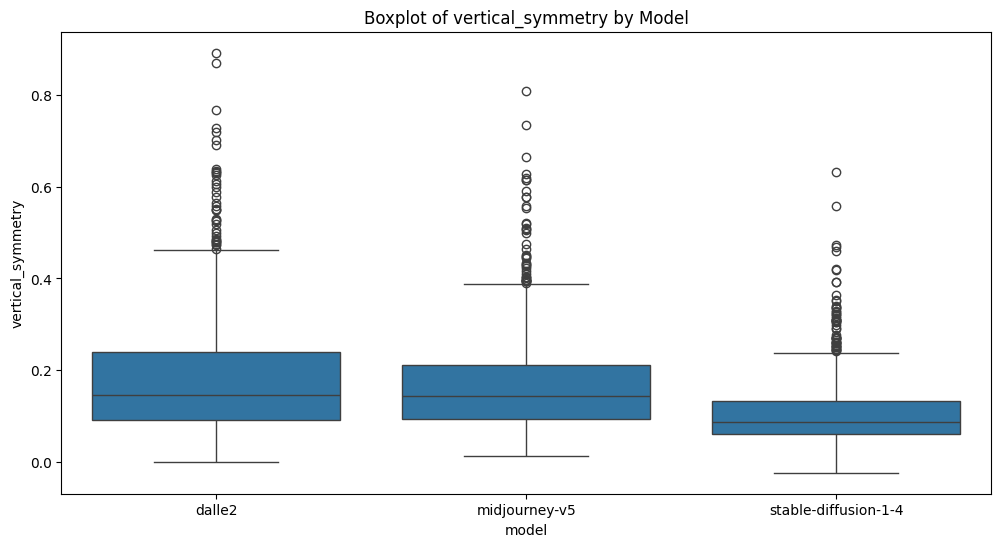

analysis for column : sharpness
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 147.1521 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for sharpness


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


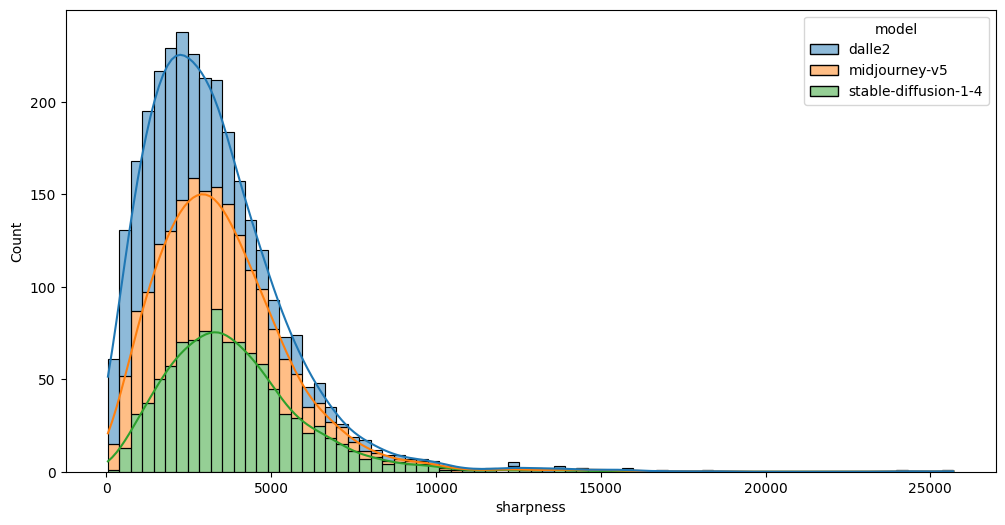

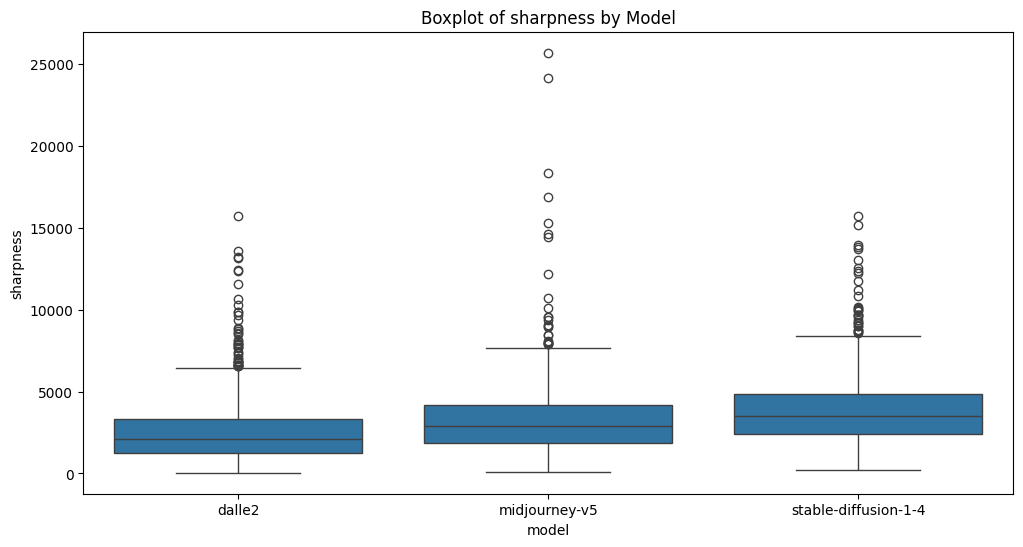

analysis for column : edge_density
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 561.2451 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for edge_density


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


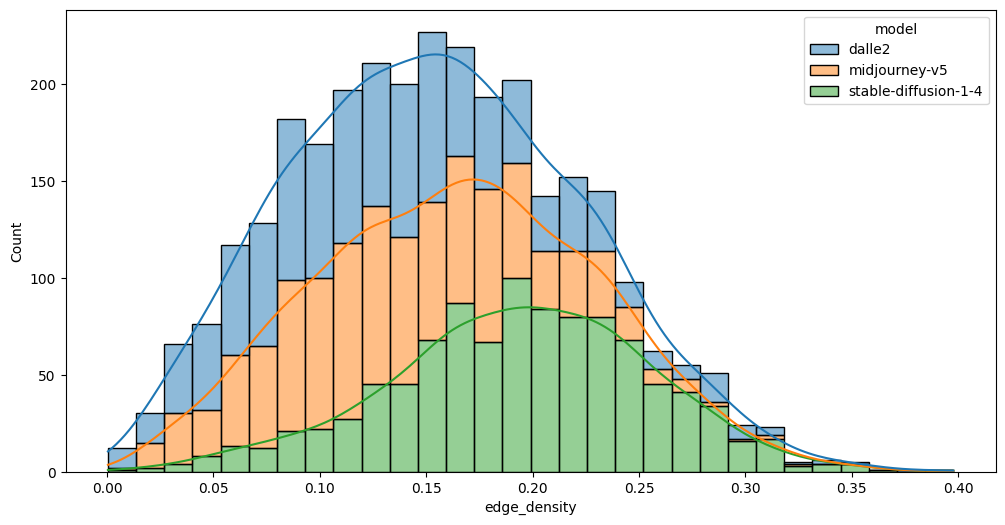

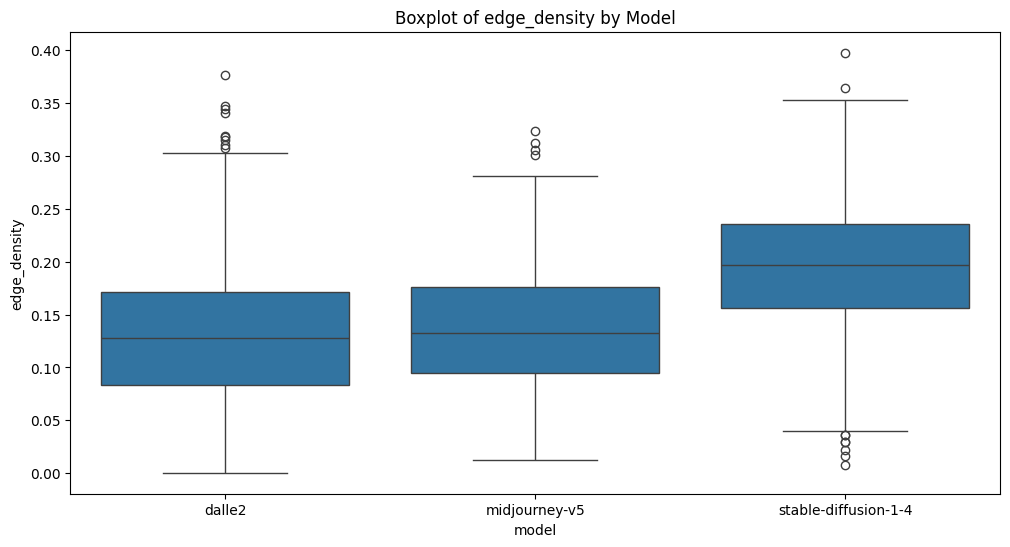

analysis for column : whitespace_ratio
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 185.7012 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for whitespace_ratio


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


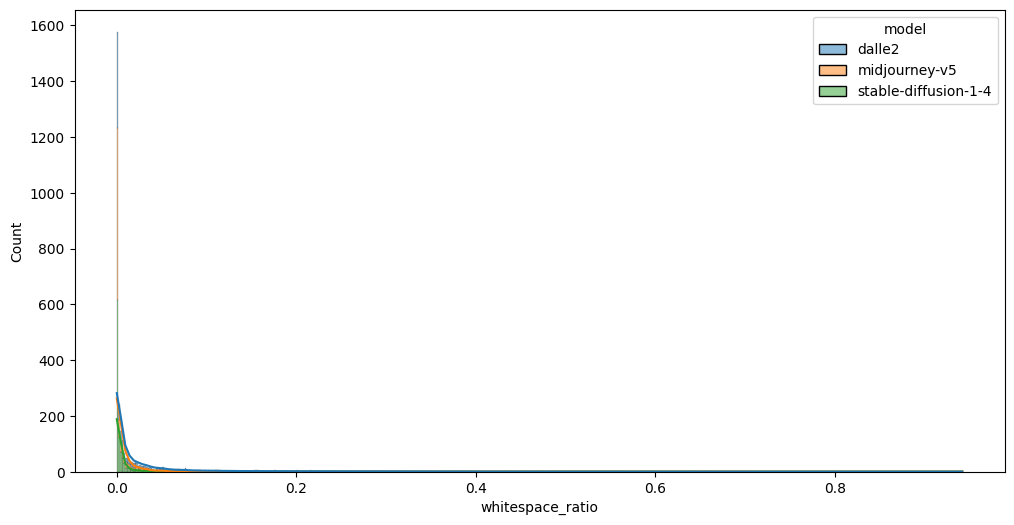

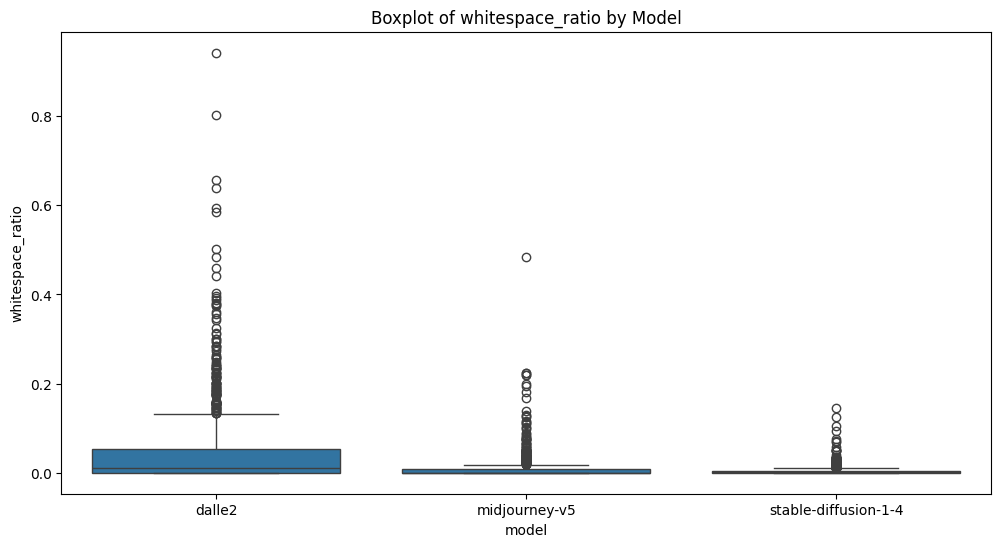

analysis for column : most_common_color_R
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 233.1849 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_color_R


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


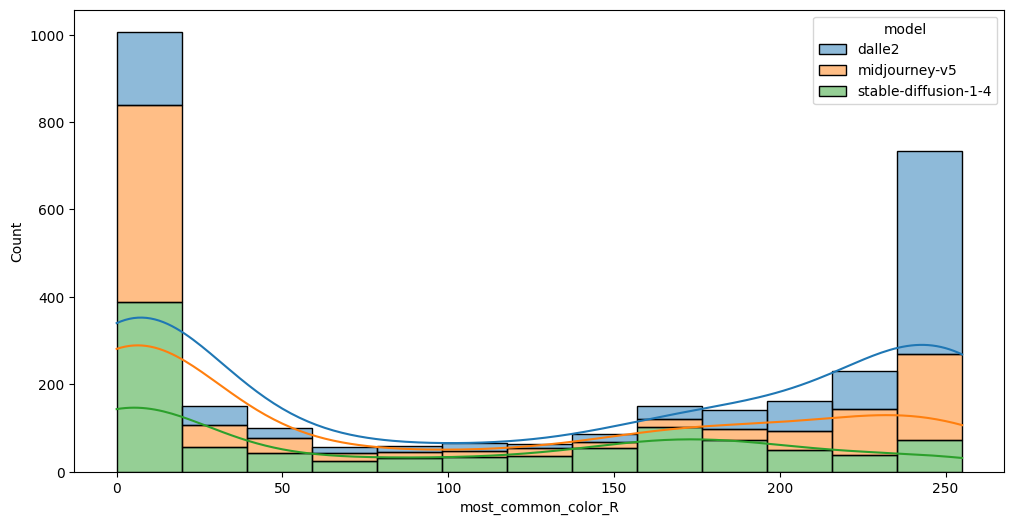

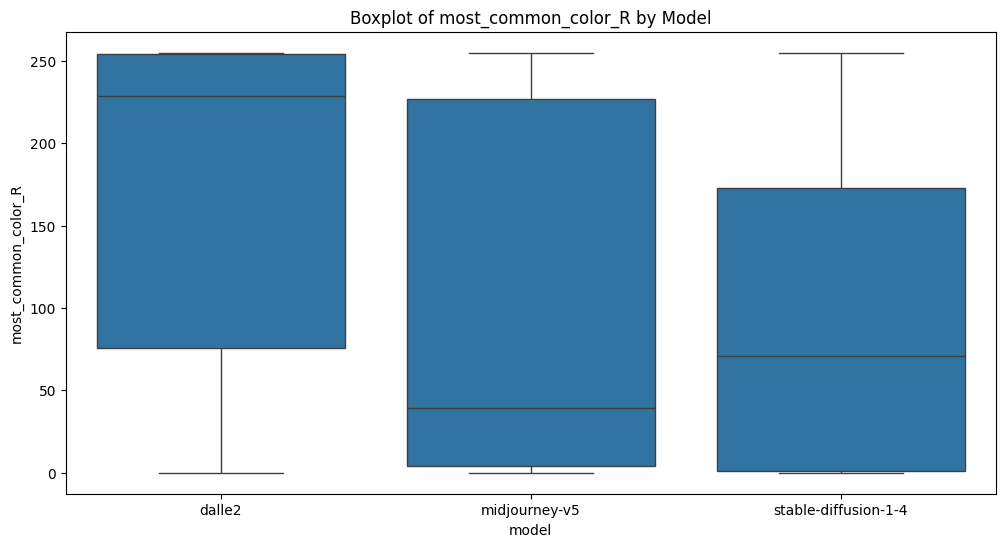

analysis for column : most_common_color_G
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 263.5866 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_color_G


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


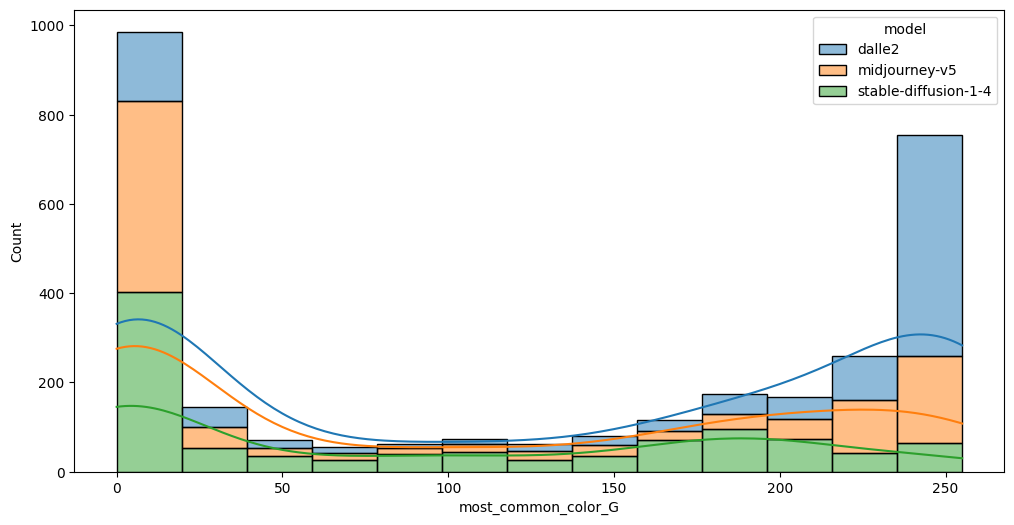

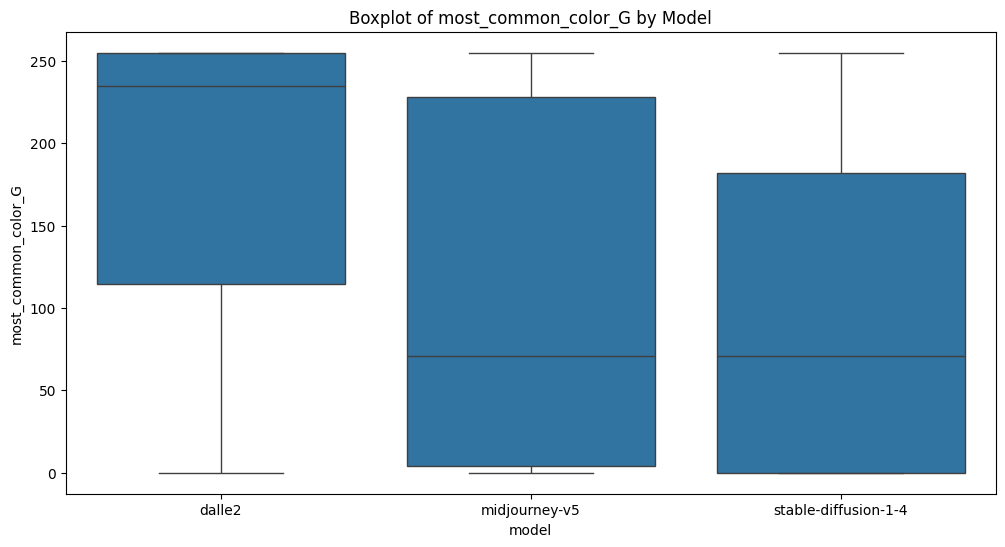

analysis for column : most_common_color_B
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 251.4402 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_color_B


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


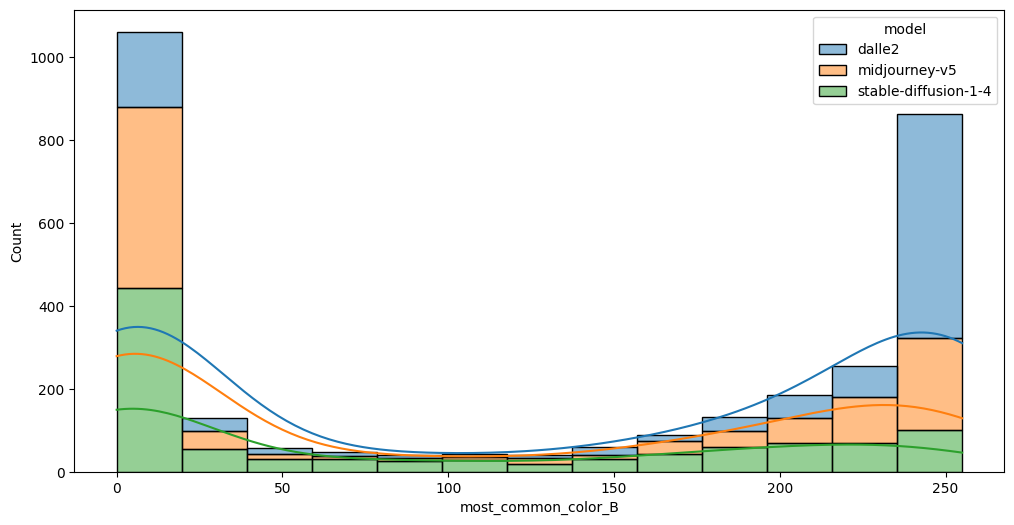

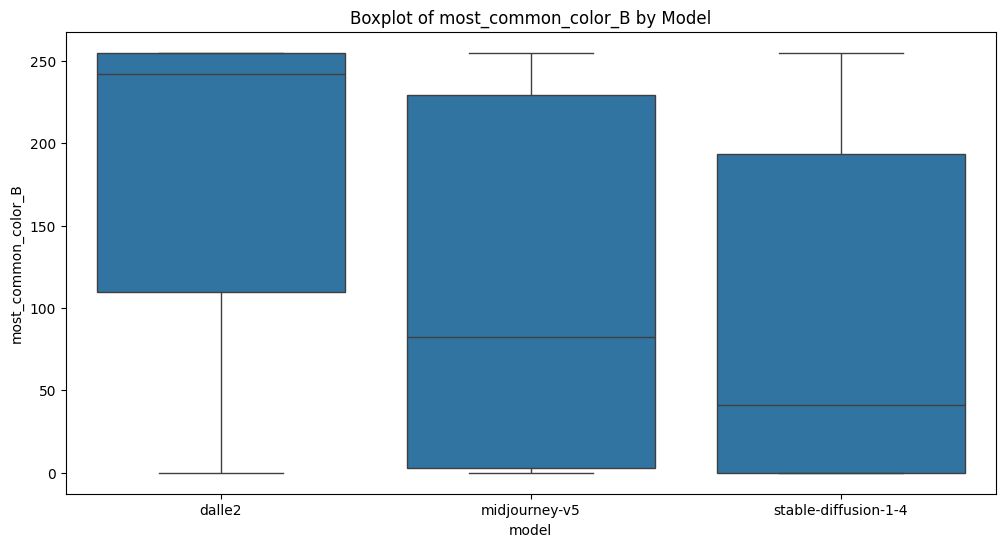

analysis for column : least_common_color_R
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 101.6474 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for least_common_color_R


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


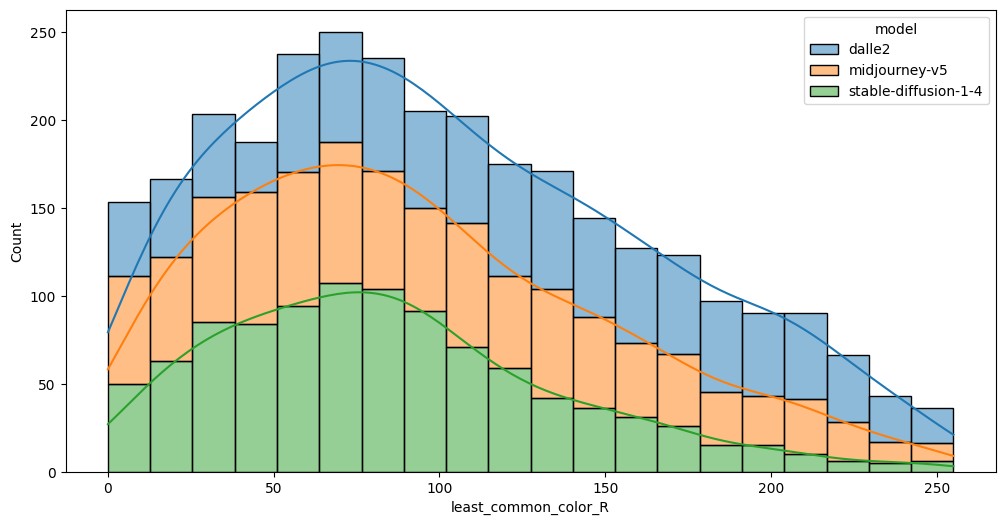

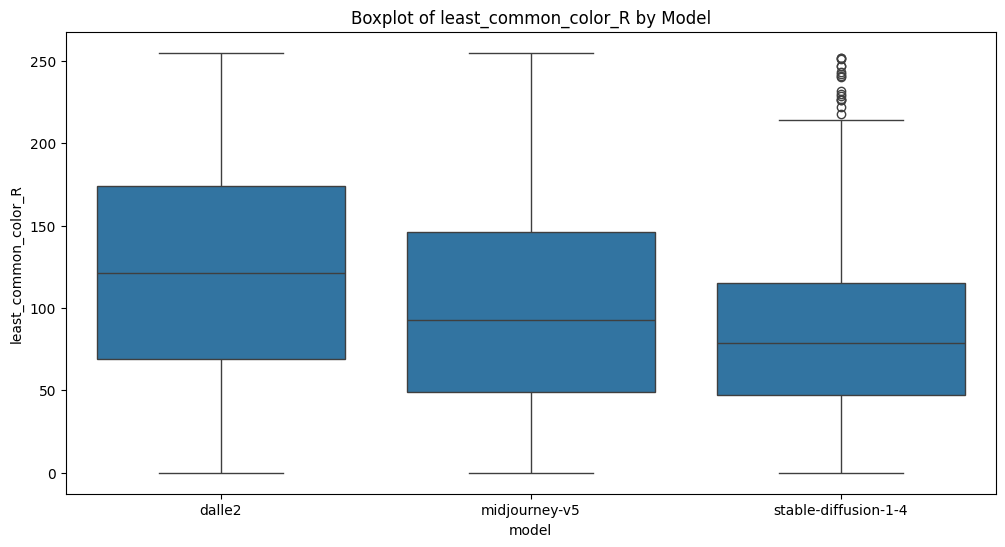

analysis for column : least_common_color_G
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model 80.0915 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for least_common_color_G


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


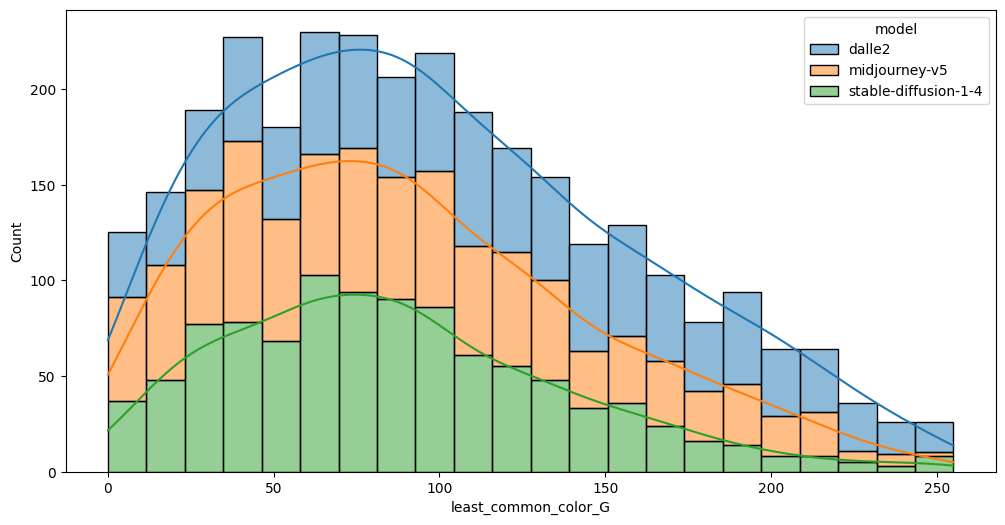

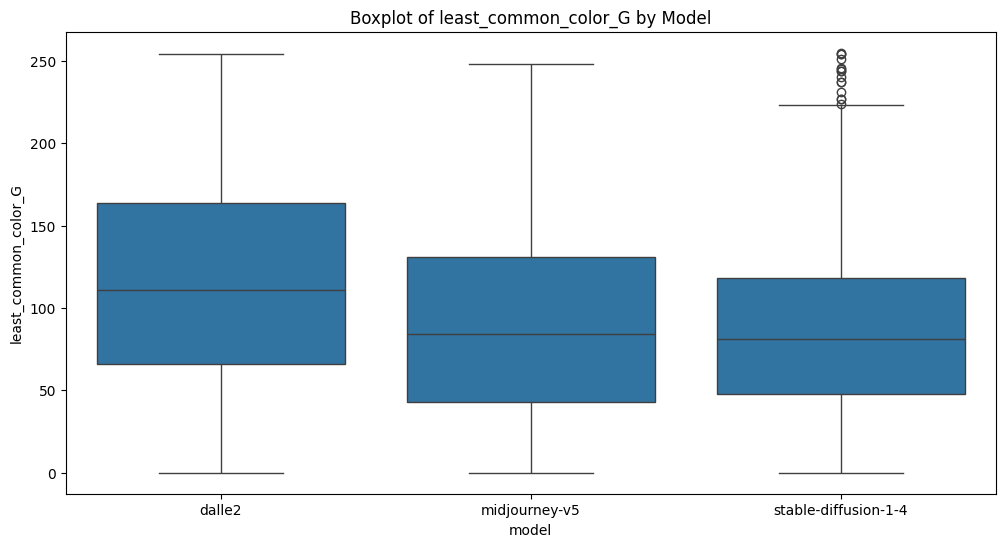

analysis for column : least_common_color_B
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model 59.5490 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for least_common_color_B


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


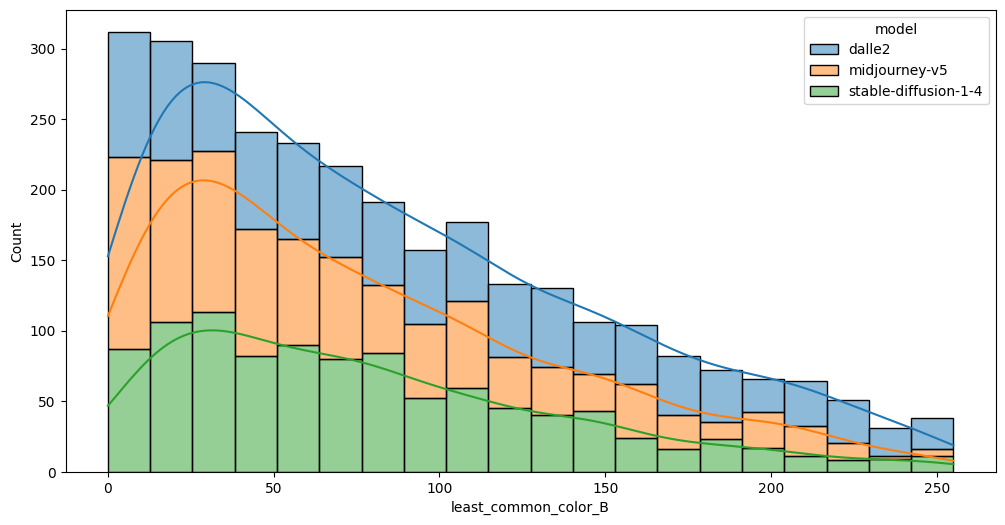

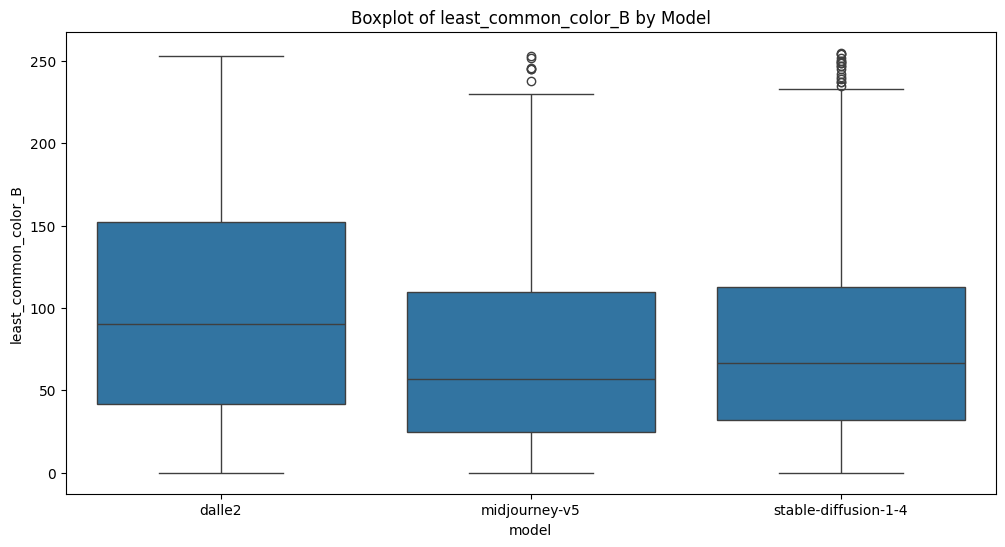

analysis for column : most_common_percentage_1
                Anova
      F Value Num DF   Den DF  Pr > F
-------------------------------------
model 71.3931 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_percentage_1


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


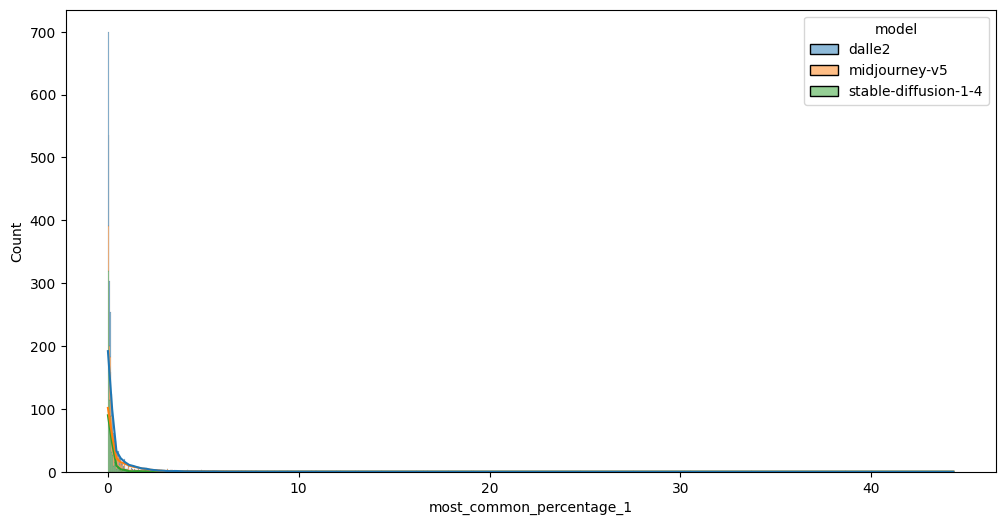

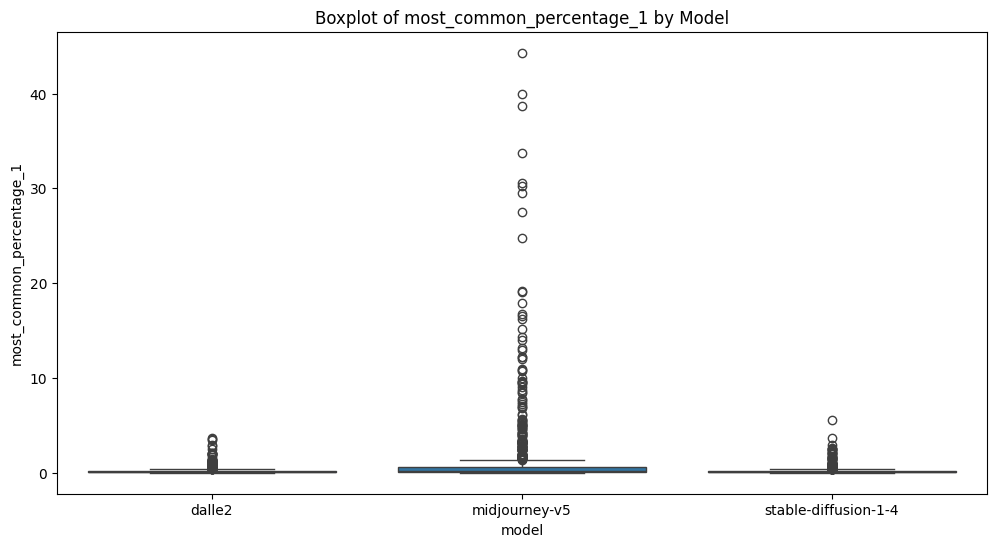

analysis for column : most_common_percentage_2
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 105.8789 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_percentage_2


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


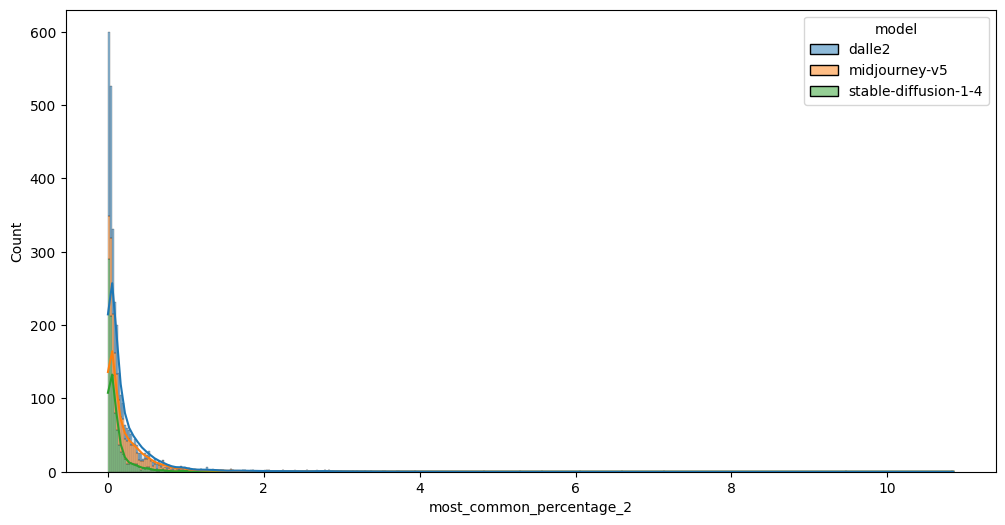

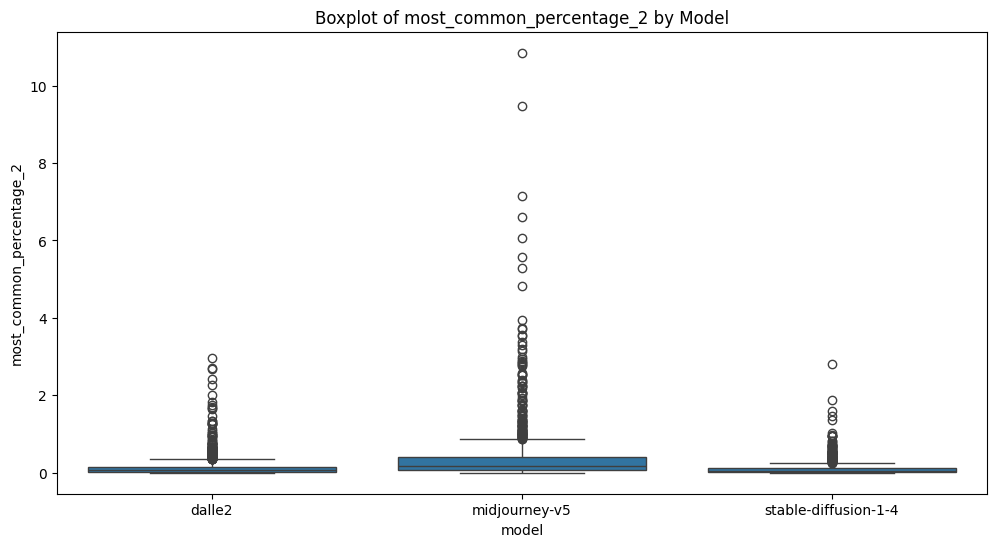

analysis for column : most_common_percentage_3
                Anova
      F Value  Num DF   Den DF  Pr > F
--------------------------------------
model 120.4321 2.0000 1998.0000 0.0000


Yinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):
Plotting histogram for most_common_percentage_3


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_6129/3360818166.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz


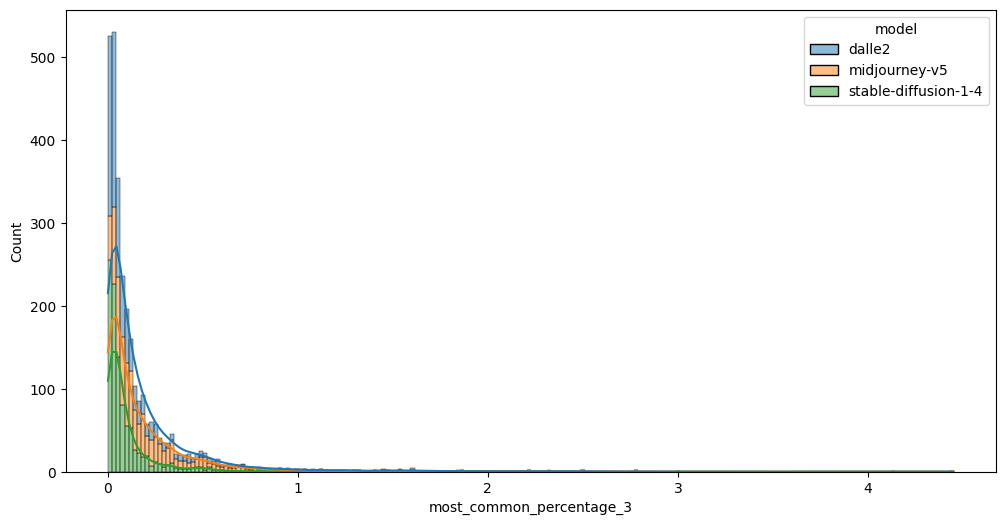

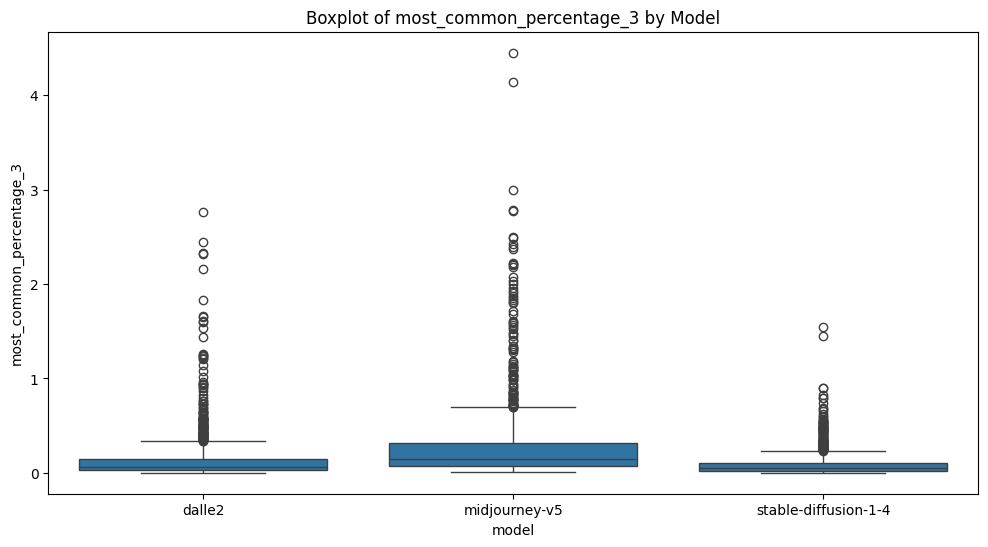

In [14]:
from statsmodels.stats.anova import AnovaRM
import matplotlib.pyplot as plt
import seaborn as sns

distinct_features=[]


for column in all_df.drop(columns=['image', 'prompt', 'model']).columns:
    print("analysis for column : " + column)

    aovrm = AnovaRM(data=all_df, depvar=column, subject='prompt', within=['model'])
    res = aovrm.fit()
    print(res)
    p_value = res.anova_table["Pr > F"][0]  # p-değerini çekiyoruz
    if p_value < 0.005:
        distinct_features.append(column)
    print("\nYinelenen Ölçümler ANOVA Sonuçları (Karışık Veri ile):")
    

    print(f"Plotting histogram for {column}")
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(data=all_df, x=column, hue='model', multiple='stack', kde=True)
    palette = {'dalle2': 'blue', 'midjourney-v5': 'green', 'stable-diffusion-1-4': 'red'}

  
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='model', y=column, data=all_df)
    plt.title(f'Boxplot of {column} by Model')
    plt.show()


In [ ]:
print(len(all_df.columns)) # 3 of them are images prompt and model columns so only 1 eliminated
print(len(distinct_features))

#not very helpful

24
20


## RFE feature selector


Accuracy: 0.72
                      precision    recall  f1-score   support

              dalle2       0.78      0.80      0.79       200
       midjourney-v5       0.73      0.56      0.64       200
stable-diffusion-1-4       0.66      0.80      0.72       200

            accuracy                           0.72       600
           macro avg       0.72      0.72      0.72       600
        weighted avg       0.72      0.72      0.72       600

Accuracy: 0.75
                      precision    recall  f1-score   support

              dalle2       0.84      0.80      0.82       200
       midjourney-v5       0.74      0.61      0.67       200
stable-diffusion-1-4       0.69      0.83      0.75       200

            accuracy                           0.75       600
           macro avg       0.76      0.75      0.75       600
        weighted avg       0.76      0.75      0.75       600

Accuracy: 0.725
                      precision    recall  f1-score   support

              dal

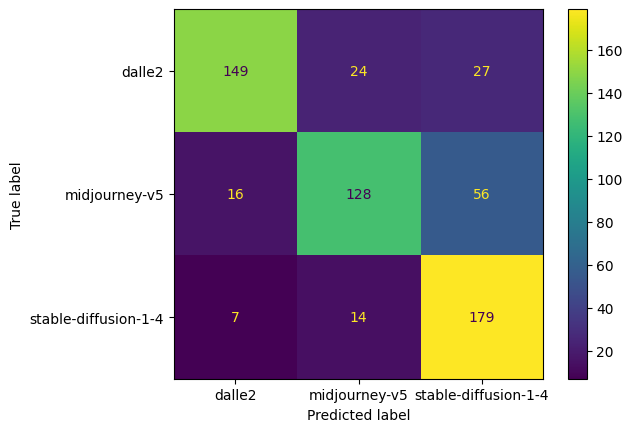

In [ ]:
# Step 0: Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

svm_accuracies = []
best_accuracy = 0
best_model = None

for i in range(7):
    # Step 1: Define X and y
    # Assuming 'df' is your full DataFrame and the last column is the target
    X = all_df.drop(columns=['image','prompt','model'])
    y = all_df['model']

    # Step 2: Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )

    # Step 3: Use Random Forest for feature selection (RFE)
    rf_classifier = RandomForestClassifier(random_state=i)
    selector = RFE(rf_classifier, n_features_to_select=10)
    selector = selector.fit(X_train, y_train)

    # Step 4: Get selected features
    selected_features = X_train.columns[selector.support_]
    #print("Selected features:", selected_features)

    # Step 5: Filter datasets by selected features
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # Step 6: (Recommended) Scale features for SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_test_scaled = scaler.transform(X_test_selected)

    # Step 7: Train SVM classifier
    svm_classifier = SVC(kernel='rbf', random_state=i)
    svm_classifier.fit(X_train_scaled, y_train)

    # Step 8: Evaluate
    y_pred = svm_classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    svm_accuracies.append(accuracy)
    print(classification_report(y_test, y_pred))

    if best_accuracy < accuracy:
        best_accuracy = accuracy
        best_model = svm_classifier
    

ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test)
print("best accuracy: " , best_accuracy)
print("averag eaccuracy : " , np.mean(svm_accuracies) )
